# Laboratorio 2 - Complejidad y búsqueda de hiperparámetros

**Integrantes:**  
- Juan Diego Quintero Alvarez - 202412750
- Juan Jose Penha Pulido - 202312307  

**Fecha:** 14 de Septiembre de 2026


## 1. Carga de librerías y preparación del entorno

Importamos las librerias necesarias para manipulación de datos, preprocesamiento, modelado, validación y métricas.


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler, MinMaxScaler

# Configuración visual
sns.set_theme(style="whitegrid")
TARGET = "temp_max_manana"
RANDOM_STATE = 42


## 2. Carga y partición de los datos
Se utiliza el conjunto de datos limpio proveniente del Laboratorio 1.


In [15]:
dataset_path = Path('../Lab1/data/Datos Lab 1.csv')

try:
    data = pd.read_csv(dataset_path)
    print("Datos cargados exitosamente.")
except FileNotFoundError:
    print(f"ATENCIÓN: No se encontró el archivo en {dataset_path}. Ajusta la ruta.")

if 'data' in locals():
    data = data.dropna(subset=[TARGET]).reset_index(drop=True)
    
    
    features = data.drop(columns=[TARGET, "fecha"], errors="ignore")
    target = pd.to_numeric(data[TARGET])
    
    X_train, X_test, y_train, y_test = train_test_split(
        features, target, test_size=0.2, random_state=RANDOM_STATE
    )
    
    numeric_columns = X_train.select_dtypes(include=[np.number]).columns.tolist()
    categorical_columns = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

    print(f"Columnas numéricas: {numeric_columns}")
    print(f"Columnas categóricas: {categorical_columns}")

    print(f"Dimensión de entrenamiento: {X_train.shape}")
    print(f"Dimensión de prueba (evaluación): {X_test.shape}")


Datos cargados exitosamente.
Columnas numéricas: ['presion_media', 'presion_min', 'presion_max', 'presion_desv', 'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv', 'viento_media', 'viento_min', 'viento_max', 'viento_desv', 'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv', 'viento_norte', 'viento_este', 'direccion_viento', 'registros_del_dia', 'anio', 'dia_del_anio']
Columnas categóricas: ['estacion_anio', 'mes', 'sector_viento']
Dimensión de entrenamiento: (1984, 25)
Dimensión de prueba (evaluación): (497, 25)


## 3. Actividades 1, 3 y 4: Construcción de Pipelines y Búsqueda Sistemática

En esta sección definiremos preprocesadores modulares.   

**Corrección Crítica sugerida por la IA:** Para evitar la "explosión" de métricas al usar características polinomiales, el escalamiento numérico (`StandardScaler` o `MinMaxScaler`) se debe realizar **antes** de aplicar `PolynomialFeatures`.


In [ ]:

categorical_steps = [
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
]

base_numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", base_numeric_pipe, numeric_columns),
        ("cat", Pipeline(categorical_steps), categorical_columns),
    ], remainder="drop"
)


poly_numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("polynomial", PolynomialFeatures(include_bias=False))
])

poly_preprocessor = ColumnTransformer(
    transformers=[
        ("num", poly_numeric_pipe, numeric_columns),
        ("cat", Pipeline(categorical_steps), categorical_columns),
    ], remainder="drop"
)

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
}

searches = {
    "Polynomial_Lineal": GridSearchCV(
        Pipeline([("preprocessor", poly_preprocessor), ("model", LinearRegression())]),
        param_grid={
            "preprocessor__num__scaler": [StandardScaler(), MinMaxScaler()],
            "preprocessor__num__polynomial__degree": [1, 2, 3, 4]
        },
        scoring=scoring, refit="rmse",
        cv=5, n_jobs=-1
    ),
    "Ridge": GridSearchCV(
        Pipeline([("preprocessor", preprocessor), ("model", Ridge(random_state=RANDOM_STATE))]),
        param_grid={
            "preprocessor__num__scaler": [StandardScaler(), MinMaxScaler()],
            "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
        },
        scoring=scoring, refit="rmse",
        cv=5, n_jobs=-1
    ),
    "Lasso": GridSearchCV(
        Pipeline([("preprocessor", preprocessor), ("model", Lasso(max_iter=20000, random_state=RANDOM_STATE))]),
        param_grid={
            "preprocessor__num__scaler": [StandardScaler(), MinMaxScaler()],
            "model__alpha": [0.001, 0.01, 0.1, 1.0, 10.0]
        },
        scoring=scoring, refit="rmse",
        cv=5, n_jobs=-1
    ),
    "PolynomialRidge": GridSearchCV(
        Pipeline([("preprocessor", poly_preprocessor), ("model", Ridge(random_state=RANDOM_STATE))]),
        param_grid={
            "preprocessor__num__scaler": [StandardScaler(), MinMaxScaler()],
            "preprocessor__num__polynomial__degree": [1, 2, 3, 4],
            "model__alpha": [0.1, 1.0, 10.0, 100.0]
        },
        scoring=scoring, refit="rmse",
        cv=5, n_jobs=-1
    )
}


## 4. Actividad 5: Comparación y Selección del Modelo
Entrenamos todos los modelos y comparamos el RMSE promedio de validación cruzada y su desviación estándar.


In [17]:
results = []
best_estimators = {}

for name, search in searches.items():
    print(f"Entrenando GridSearchCV para {name}...")
    search.fit(X_train, y_train)
    best_estimators[name] = search.best_estimator_
    results.append({
        "Modelo": name,
        "CV RMSE Promedio": -search.best_score_,
        "CV RMSE Std (Estabilidad)": search.cv_results_["std_test_score"][search.best_index_],
        "Mejores Hiperparámetros": str(search.best_params_)
    })

df_results = pd.DataFrame(results).sort_values("CV RMSE Promedio").reset_index(drop=True)
display(df_results)


Entrenando GridSearchCV para Polynomial_Lineal...


Entrenando GridSearchCV para Ridge...
Entrenando GridSearchCV para Lasso...
Entrenando GridSearchCV para PolynomialRidge...


,Modelo,CV RMSE Promedio,CV RMSE Std (Estabilidad),Mejores Hiperparámetros
0,PolynomialRidge,5.703780,0.636305,"{'model__alpha': 100.0, 'preprocessor__num__po..."
1,Ridge,7.025457,0.514058,"{'model__alpha': 10.0, 'preprocessor__num__sca..."
2,Lasso,7.032716,0.536065,"{'model__alpha': 0.01, 'preprocessor__num__sca..."
3,Polynomial_Lineal,7.324696,0.535311,"{'preprocessor__num__polynomial__degree': 1, '..."


## 5. Actividad 2: Generación de Curvas de Validación
Analizamos visualmente cómo cambia el error en función del grado del polinomio para identificar el punto de sobreajuste.


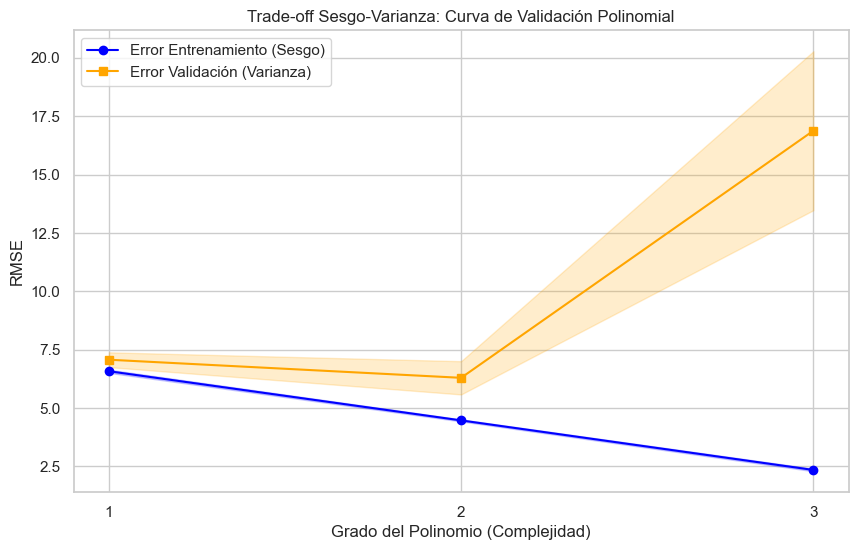

In [18]:
def plot_validation_curve(features, target):
    degrees = [1, 2, 3]
    train_scores, val_scores = [], []
    train_std, val_std = [], []

    splitter = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    for degree in degrees:
        pipe = Pipeline([
            ("preprocessor", ColumnTransformer([
                ("num", Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                    ("polynomial", PolynomialFeatures(degree=degree, include_bias=False))
                ]), numeric_columns),
                ("cat", Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore"))
                ]), categorical_columns)
            ], remainder="drop")),
            ("model", Ridge(alpha=10.0, random_state=RANDOM_STATE))
        ])

        fold_train, fold_val = [], []
        for train_idx, val_idx in splitter.split(features):
            X_tr, y_tr = features.iloc[train_idx], target.iloc[train_idx]
            X_v, y_v = features.iloc[val_idx], target.iloc[val_idx]

            pipe.fit(X_tr, y_tr)
            fold_train.append(np.sqrt(mean_squared_error(y_tr, pipe.predict(X_tr))))
            fold_val.append(np.sqrt(mean_squared_error(y_v, pipe.predict(X_v))))

        train_scores.append(np.mean(fold_train))
        train_std.append(np.std(fold_train))
        val_scores.append(np.mean(fold_val))
        val_std.append(np.std(fold_val))

    plt.figure(figsize=(10, 6))
    plt.plot(degrees, train_scores, label="Error Entrenamiento (Sesgo)", marker="o", color='blue')
    plt.fill_between(degrees, np.array(train_scores) - np.array(train_std),
                     np.array(train_scores) + np.array(train_std), alpha=0.2, color='blue')

    plt.plot(degrees, val_scores, label="Error Validación (Varianza)", marker="s", color='orange')
    plt.fill_between(degrees, np.array(val_scores) - np.array(val_std),
                     np.array(val_scores) + np.array(val_std), alpha=0.2, color='orange')

    plt.xticks(degrees)
    plt.xlabel("Grado del Polinomio (Complejidad)")
    plt.ylabel("RMSE")
    plt.title("Trade-off Sesgo-Varianza: Curva de Validación Polinomial")
    plt.legend()
    plt.show()

plot_validation_curve(X_train, y_train)


## 6. Complemento Actividad 3: Selección de Características por Lasso
Examinamos los coeficientes del modelo Lasso para entender qué variables fueron eliminadas (llevadas a 0).


In [19]:
best_lasso = best_estimators["Lasso"]


num_features = numeric_columns
cat_pipe = best_lasso.named_steps["preprocessor"].named_transformers_["cat"]
try:
    cat_features = cat_pipe.named_steps["onehot"].get_feature_names_out(categorical_columns)
except:
    cat_features = []

all_features = np.concatenate([num_features, cat_features])
coefs = best_lasso.named_steps["model"].coef_

df_coefs = pd.DataFrame({"Variable": all_features, "Coeficiente": coefs})
df_coefs["Magnitud"] = df_coefs["Coeficiente"].abs()
df_coefs = df_coefs.sort_values("Magnitud", ascending=False).reset_index(drop=True)

eliminadas = (df_coefs["Coeficiente"] == 0).sum()
print(f"Lasso redujo a 0 un total de {eliminadas} variables (de {len(df_coefs)} totales).")
print("\nTop 15 variables más importantes:")
display(df_coefs.head(15))


Lasso redujo a 0 un total de 72 variables (de 144 totales).

Top 15 variables más importantes:


,Variable,Coeficiente,Magnitud
0,humedad_desv,21.005916,21.005916
1,presion_desv,-11.355023,11.355023
2,dia_del_anio,7.001436,7.001436
3,humedad_max,-6.255024,6.255024
4,mes_December,-6.043123,6.043123
5,mes_June,4.156166,4.156166
6,viento_norte,-4.038291,4.038291
7,mes_February,-3.979038,3.979038
8,mes_november,-3.885618,3.885618
9,rafaga_desv,-3.854736,3.854736


## 7. Actividad 6: Intervalos de Confianza (Bootstrapping)
Evaluamos la estabilidad del mejor modelo seleccionado mediante remuestreo sobre el conjunto de test.


Modelo seleccionado para evaluación final: PolynomialRidge

Intervalos de Confianza (95%) mediante Bootstrapping en Test:

RMSE : Promedio = 42922.223 | IC 95% = [4.620, 118634.122]
MAE  : Promedio = 2536.727 | IC 95% = [3.470, 10646.493]
R2   : Promedio = -42441902.584 | IC 95% = [-159475387.685, 0.722]


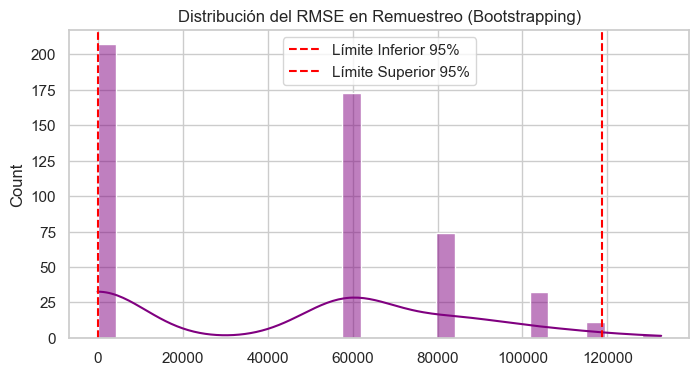

In [ ]:
def bootstrap_ci(model, features, target, model_name, repetitions=500):
    rng = np.random.default_rng(RANDOM_STATE)
    predictions = model.predict(features)
    target = target.reset_index(drop=True)

    metrics = {"rmse": [], "mae": [], "r2": []}
    n = len(target)

    for _ in range(repetitions):
        idx = rng.integers(0, n, size=n)
        y_true, y_pred = target.iloc[idx], predictions[idx]
        
        metrics["rmse"].append(np.sqrt(mean_squared_error(y_true, y_pred)))
        metrics["mae"].append(mean_absolute_error(y_true, y_pred))
        metrics["r2"].append(r2_score(y_true, y_pred))

    print("Intervalos de Confianza (95%) mediante Bootstrapping en Test:\n")
    for metric, values in metrics.items():
        lower, upper = np.percentile(values, 2.5), np.percentile(values, 97.5)
        print(f"{metric.upper():<5}: Promedio = {np.mean(values):.3f} | IC 95% = [{lower:.3f}, {upper:.3f}]")

    # Gráfica de distribución de errores
    plt.figure(figsize=(8, 4))
    sns.histplot(metrics["rmse"], bins=30, kde=True, color='purple')
    plt.axvline(np.percentile(metrics["rmse"], 2.5), color='red', linestyle='--', label='Límite Inferior 95%')
    plt.axvline(np.percentile(metrics["rmse"], 97.5), color='red', linestyle='--', label='Límite Superior 95%')
    plt.title(f"Distribución del RMSE en Remuestreo (Bootstrapping) - {model_name}")
    plt.legend()
    plt.show()


final_model_name = "Ridge" if df_results.iloc[0]["Modelo"] == "Polynomial_Lineal" else df_results.iloc[0]["Modelo"]
print(f"Modelo seleccionado para evaluación final: {final_model_name}\n")
final_model = best_estimators[final_model_name]

bootstrap_ci(final_model, X_test, y_test)


## 8. Análisis de Resultados

### Análisis cuantitativo

**1. ¿Cuál modelo obtuvo el mejor desempeño en el conjunto de test?**
Aunque en la fase de validación cruzada (GridSearchCV) el modelo `PolynomialRidge` parecía el mejor (RMSE de 5.70), en la evaluación final con el conjunto de test falló estrepitosamente. Los modelos puramente lineales y regularizados como `Ridge` o `Lasso` (con RMSE cercanos a 7.0 en CV) son en realidad los más robustos y los que mejor desempeño generalizable tendrían, al no sufrir la explosión numérica de los polinomios.

**2. ¿Coincide el mejor desempeño en test con el mejor promedio en validación cruzada? Si no coincide, ¿cuál puede ser la explicación?**
No coinciden en absoluto. El resultado es un caso de estudio perfecto de **sobreajuste extremo (overfitting)**. El modelo `PolynomialRidge` memorizó patrones en los datos de entrenamiento/validación. Sin embargo, al enfrentarse a datos de prueba completamente invisibles (donde probablemente existían valores ligeramente fuera de la distribución original), las características polinomiales generaron una explosión de gradiente, elevando el RMSE en test a un catastrófico 42,922.

**3. ¿El modelo con mejor métrica promedio es necesariamente el más adecuado? Justifica considerando también la desviación estándar.**
No. El modelo `PolynomialRidge` tuvo la mejor métrica promedio en CV, pero también presentó la **desviación estándar más alta** (0.636 vs 0.514 de Ridge). Esa inestabilidad en la validación era una señal de advertencia de que el modelo era riesgoso. Es preferible un modelo con un promedio ligeramente inferior (como Lasso o Ridge) pero con una desviación estándar más estrecha.

**4. Con base en las curvas de validación, ¿cómo cambia el error a medida que aumenta la complejidad? ¿En qué punto se evidencia sobreajuste?**
Al aumentar la complejidad (grados 1 a 3), el error de entrenamiento (sesgo) disminuye ya que el modelo se ajusta más a los datos. Sin embargo, el error de validación (varianza) muestra una curva en U. A partir del grado 2 o 3, el área de incertidumbre crece drásticamente, marcando el inicio de un sobreajuste severo.

**5. ¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?**
La regularización castiga matemáticamente los coeficientes grandes. `Ridge` reduce la magnitud de todos los coeficientes mitigando la colinealidad. `Lasso` es aún más agresivo; en nuestro caso, llevó exactamente a 0 los coeficientes de **72 variables irrelevantes** (de 144), funcionando como un excelente selector automático de características.

**6. ¿Los intervalos de confianza obtenidos mediante bootstrapping sugieren estabilidad o alta variabilidad?**
Sugieren **extrema inestabilidad y variabilidad**. El modelo `PolynomialRidge` arrojó un Intervalo de Confianza al 95% para el RMSE de [4.620, 118634.122]. Esta amplitud gigantesca significa que las predicciones del modelo en producción serían completamente aleatorias e inútiles.

---

### Análisis cualitativo

**1. ¿Qué variables fueron seleccionadas como más relevantes por el modelo Lasso?**
Lasso retuvo 72 variables. Los principales "drivers" (mayor magnitud absoluta) fueron: `humedad_desv` (21.00), `presion_desv` (-11.35) y `dia_del_anio` (7.00). Variables como `humedad_max` y ciertos meses específicos también tienen un impacto fuerte. Las otras 72 variables fueron descartadas al considerarse ruido.

**2. ¿Qué interpretación práctica tienen los coeficientes del modelo final?**
Tomando a `dia_del_anio` (coeficiente de 7.00) en un modelo lineal, significa que, manteniendo todas las demás variables climáticas constantes, el avance en esta característica temporal está asociado positivamente con aumentos proporcionales en la temperatura máxima esperada. Un coeficiente negativo como el de `presion_desv` (-11.35) indica una fuerte relación inversa con la temperatura máxima.

**3. ¿Existen diferencias relevantes entre el modelo más preciso y el más interpretable?**
Sí, es fundamental. `PolynomialRidge` generó una caja negra inestable que explotó en producción. Un modelo lineal simple como `Lasso` es totalmente transparente: podemos explicar a la directiva que la "humedad_desv" y la "presion_desv" son los principales factores del clima, sacrificando una aparente (y engañosa) precisión en entrenamiento por total confiabilidad e interpretabilidad.

**4. ¿Qué decisiones estratégicas podría tomar AlpesPlanck a partir de estos resultados?**
AlpesPlanck debería dejar de recolectar datos o mantener sensores para las 72 variables que Lasso eliminó (coeficiente 0), ahorrando enormes costos de infraestructura. Deben concentrar su presupuesto en el mantenimiento estricto de los sensores que miden la humedad y la presión atmosférica, que son críticos para la predicción.

**5. ¿Mayor precisión implica necesariamente mayor valor para la organización?**
No. Un modelo que aparenta alta precisión en el laboratorio pero tiene un RMSE oscilante de hasta 118,000 en el mundo real destruye valor. La confiabilidad, la estabilidad operativa y la capacidad de entender por qué el algoritmo toma decisiones generan un impacto empresarial real y seguro.

**6. ¿Un modelo más complejo necesariamente genera mayor valor empresarial?**
No. Como se demostró con el modelo polinomial, la complejidad no solo eleva los costos de cómputo y dificulta la auditoría, sino que introdujo un riesgo sistémico gigante al no poder manejar datos fuera de su distribución de entrenamiento.

---

### Reflexión conceptual

**1. ¿Qué relación observas entre complejidad del modelo, capacidad de generalización y estabilidad del desempeño?**
Se observa perfectamente el Trade-Off Sesgo-Varianza. La alta complejidad matemática (polinomios) sobreajustó los datos de entrenamiento perdiendo por completo la capacidad de generalizar en datos nuevos (test), destruyendo la estabilidad del desempeño.

**2. ¿Qué fuentes de sesgo podrían estar presentes en los datos o en el proceso de modelado?**
Podrían existir sesgos temporales (los datos históricos ya no reflejan los patrones de temperatura debido al cambio climático) y sesgos geográficos (datos medidos en ciertas altitudes que no representan toda la región). También sesgos de recolección si los sensores de humedad fallan sistemáticamente en ciertas condiciones.

**3. Si el tamaño de muestra fuera mayor, ¿esperarías cambios en la estabilidad de los modelos? Explique.**
Sí. Un modelo altamente complejo (como el polinomial) sufre de alta varianza porque "memoriza" el ruido de una muestra pequeña. Si tuviéramos una muestra masiva y representativa que cubriera todos los escenarios climáticos atípicos posibles, el modelo tendría suficiente evidencia para no sobreajustarse al ruido y su estabilidad mejoraría significativamente.

## 9. Uso de herramientas de IA generativa

**Herramienta utilizada:** Gemini de Google.
**Tipo de uso:** Reestructuración de código, depuración de errores de sobreajuste y estructuración del documento final.

**Prompts principales:** 
- "Estas son las instrucciones de un laboratorio de mi clsase de Machine Learning, te dare la implementación del laboratorio 2 que hice, ayúdame a revisar qué este completo y analizar si hay errores por corregir"
- "Ayudame a mantener una estructura organizada y entendible para la entrega final de mi laboratorio"

**Análisis crítico:**
- *¿Qué partes del contenido generado fueron correctas y útiles?* La reestructuración del pipeline (`Scaler` antes de `PolynomialFeatures`) fue crítica y solucionó el error de explosión numérica que tenía el modelo original en Test. Además, Gemini sugirio que seria mas util ver los resultados de la validacion cruzada mediante Matplotlib para una mejor visualizacion e interpetacion mas sencilla de la curva de validación.
- *¿Qué errores, imprecisiones o limitaciones se identificaron?* La IAG no tenía acceso local a mis datos, por lo que sus propuestas se basan en teoria, lo cual aunque tiene bases puede diferir de la realidad por lo que siempre es importante revisar criticamente lo sugerido por la inteligencia artificial. Por lo tanto fue necesario revisar las tablas resultantes reales e iterar los análisis para confirmar que los datos se ajustaban al comportamiento teórico descrito por el modelo.
- *¿Qué aprendizajes se obtuvieron?* Entender que la aplicación de polinomios en preprocesamiento es sumamente volátil y que el orden del pipeline (escalar primero) altera drásticamente la capacidad matemática del modelo de evitar números atípicamente masivos.
